# Redes generativas para balanceo de fraude crediticio

Generación de transacciones sintéticas mediante una GAN para reducir el desbalance de clases y mejorar la detección de fraude.


In [ ]:
from pathlib import Path
import gzip

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_DIR = PROJECT_ROOT / "data"
COMPRESSED_PATH = DATA_DIR / "creditcard.csv.gz"

if not COMPRESSED_PATH.exists():
    parts = sorted(DATA_DIR.glob("creditcard.csv.gz.part*"))
    if not parts:
        raise FileNotFoundError("No se encontraron las partes comprimidas de creditcard.csv en data/.")
    with open(COMPRESSED_PATH, "wb") as target:
        for part in parts:
            target.write(part.read_bytes())

CREDITCARD_PATH = COMPRESSED_PATH


# Librerias

In [ ]:
# https://imbalanced-learn.org
! pip install -U -q imbalanced-learn


In [ ]:
import pandas as pd
import sklearn as sk
from sklearn import model_selection
from sklearn import metrics
from sklearn import tree

import warnings
warnings.filterwarnings("ignore")

from collections import Counter

import imblearn as im
from imblearn import under_sampling
from imblearn import over_sampling

from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn as sk

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import f1_score, precision_score, recall_score

import tensorflow as tf
from tensorflow import keras


import numpy as np
import time
import IPython

from tqdm import tqdm
from tqdm.auto import trange


# Dataset

In [ ]:
df = pd.read_csv(CREDITCARD_PATH, compression='gzip')
df = df.sample(frac=1).reset_index(drop=True) # mezcla los datos
df = (df - df.min()) / (df.max() - df.min()) # Normalizamos a [0,1]
df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.367604,0.845118,0.674888,0.817771,0.286987,0.772797,0.235880,0.265484,0.790845,0.426295,...,0.584692,0.522439,0.696498,0.430792,0.574017,0.358361,0.417887,0.297799,0.036170,0.0
1,0.261060,0.945221,0.777475,0.843465,0.170751,0.770213,0.263592,0.268704,0.786989,0.473641,...,0.557988,0.491270,0.661083,0.197106,0.576421,0.555402,0.410781,0.305193,0.000030,0.0
2,0.809384,0.958354,0.774999,0.840192,0.217577,0.769802,0.257491,0.270468,0.785643,0.456427,...,0.557770,0.484387,0.665981,0.325589,0.549202,0.449699,0.420958,0.314794,0.000175,0.0
3,0.858437,0.933236,0.775945,0.828557,0.147064,0.765718,0.264847,0.261051,0.796569,0.422691,...,0.567161,0.545209,0.661472,0.341037,0.588146,0.396250,0.414285,0.314558,0.000777,0.0
4,0.004491,0.925278,0.760552,0.873816,0.138814,0.761364,0.259549,0.265366,0.779539,0.418276,...,0.556781,0.535576,0.665469,0.393494,0.601148,0.379985,0.400507,0.302218,0.001129,0.0


In [ ]:
df.shape


(284807, 31)

In [ ]:
df['Class'].value_counts()


,count
Class,
0.0,284315
1.0,492


In [ ]:
print('No Frauds', round(df['Class'].value_counts()[0]/len(df) * 100,2), '% of the dataset')
print('Frauds', round(df['Class'].value_counts()[1]/len(df) * 100,2), '% of the dataset')


No Frauds 99.83 % of the dataset
Frauds 0.17 % of the dataset


El conjunto de datos esta desequilibrado con un 99.83% de casos no fraudulentos y un 0.17% de casos fraudulentos. Si utilizamos este dataframe como base para los modelos predictivos y análisis, se pueden obtener muchos errores y los algoritmos probablemente se sobreajustarán, ya que "asumirán" que la mayoría de las transacciones no son fraude.


Text(0.5, 1.0, 'Class Distributions \n (0: No Fraud || 1: Fraud)')

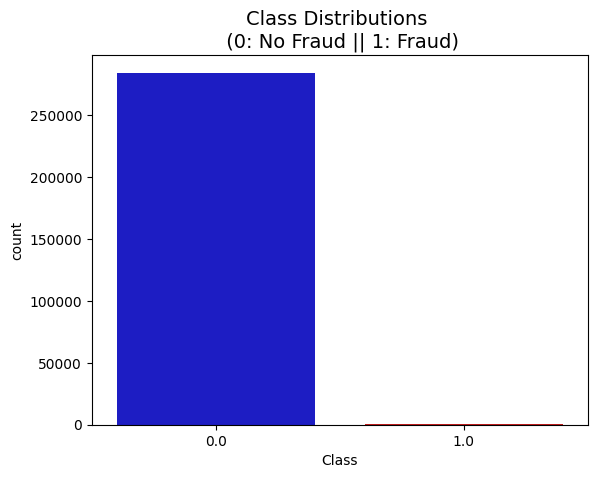

In [ ]:
colors = ["#0101DF", "#DF0101"]
sns.countplot(x='Class', data=df, palette=colors)
plt.title('Class Distributions \n (0: No Fraud || 1: Fraud)', fontsize=14)


In [ ]:
# Recorte del df
df_no_fraud = df[df['Class'] == 0]
df_fraud = df[df['Class'] == 1]
num_fraud = len(df_fraud) # Número de casos de fraude que deseas mantener
total_size = int(num_fraud / 0.2)  # El 30% de los datos serán fraude
num_no_fraud = total_size - num_fraud  # El resto serán casos sin fraude
num_no_fraud = min(num_no_fraud, len(df_no_fraud))
df_no_fraud_sample = df_no_fraud.sample(n=num_no_fraud, random_state=42)
df1= pd.concat([df_fraud, df_no_fraud_sample]).reset_index(drop=True)
print(df1['Class'].value_counts(normalize=True))


Class
0.0    0.8
1.0    0.2
Name: proportion, dtype: float64


In [ ]:
df1['Class'].value_counts()


,count
Class,
0.0,1968
1.0,492


Text(0.5, 1.0, 'Class Distributions \n (0: No Fraud || 1: Fraud)')

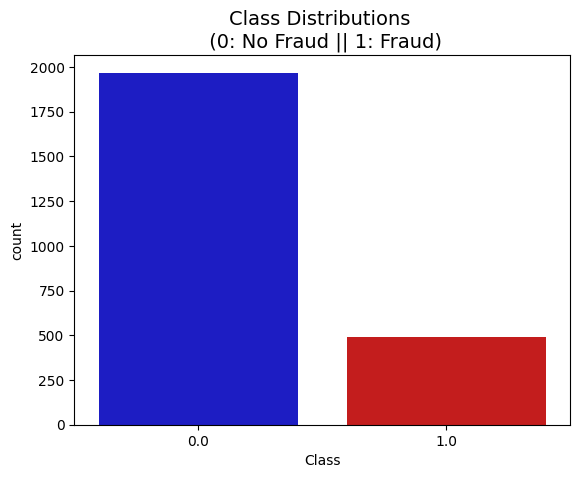

In [ ]:
colors = ["#0101DF", "#DF0101"]
sns.countplot(x='Class', data=df1, palette=colors)
plt.title('Class Distributions \n (0: No Fraud || 1: Fraud)', fontsize=14)


# MODELO 1 "Decision Tree"

In [ ]:
# Definir los datos
X = df1[df1.columns.drop("Class")] # Variables independientes
y = df1["Class"] # Variable dependiente


In [ ]:
# Definir la función para calcular métricas
def f1_precision_recall(X, y): #Le doy el x e y
# Dividir los datos en entrenamiento y prueba (50% cada uno, con estratificación)
    X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(X, y, test_size=0.5, shuffle=True, stratify=y, random_state=42)

# Crear y entrenar el modelo de árbol de decisión
    clf = sk.tree.DecisionTreeClassifier(random_state=42)
    clf.fit(X_train, y_train) #lo entrena
    y_pred = clf.predict(X_test) #predice

# Imprimir las métricas
    print("f1:", sk.metrics.f1_score(y_test, y_pred))
    print("precision:", sk.metrics.precision_score(y_test, y_pred))
    print("recall:", sk.metrics.recall_score(y_test, y_pred))


f1_precision_recall(X, y)


f1: 0.8729508196721312
precision: 0.8801652892561983
recall: 0.8658536585365854


## Peso de la clase minoritaria

In [ ]:
X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(X, y, test_size=0.5, shuffle=True, stratify=y, random_state=42)
clf = sk.tree.DecisionTreeClassifier(class_weight="balanced", random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("f1:", sk.metrics.f1_score(y_test, y_pred))
print("precision:", sk.metrics.precision_score(y_test, y_pred))
print("recall:", sk.metrics.recall_score(y_test, y_pred))


f1: 0.8467741935483871
precision: 0.84
recall: 0.8536585365853658


MODELO 1: F1 subio en la incorporación de class_weight="balanced"

# MODELO 2 "Random Forest"


In [ ]:
# Definir la función para calcular métricas
def f1_precision_recall(X, y):
    # Dividir los datos en entrenamiento y prueba (50% cada uno, con estratificación)
    X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(
        X, y, test_size=0.5, shuffle=True, stratify=y, random_state=42
    )

    # Crear y entrenar el modelo Random Forest
    clf = sk.ensemble.RandomForestClassifier(random_state=42)
    clf.fit(X_train, y_train)  # Entrenar el modelo
    y_pred = clf.predict(X_test)  # Predecir en el conjunto de prueba

    # Imprimir las métricas
    print("f1:", sk.metrics.f1_score(y_test, y_pred))
    print("precision:", sk.metrics.precision_score(y_test, y_pred))
    print("recall:", sk.metrics.recall_score(y_test, y_pred))

f1_precision_recall(X, y)


f1: 0.9190371991247265
precision: 0.995260663507109
recall: 0.8536585365853658


In [ ]:
# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, shuffle=True, stratify=y, random_state=42)

# Crear el modelo de Random Forest
clf = RandomForestClassifier(class_weight="balanced", random_state=42, n_estimators=100, max_depth=None)

# Entrenar el modelo
clf.fit(X_train, y_train)

# Predecir en el conjunto de prueba
y_pred = clf.predict(X_test)

# Evaluar el modelo
print("f1:", f1_score(y_test, y_pred))
print("precision:", precision_score(y_test, y_pred))
print("recall:", recall_score(y_test, y_pred))


f1: 0.9210526315789473
precision: 1.0
recall: 0.8536585365853658


MODELO 2: F1 subio en la incorporación de class_weight="balanced"

# MODELO 3 "Gradient Boosting"

In [ ]:
# Dividir los datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, stratify=y, random_state=42)

# Crear el modelo Gradient Boosting
gbt = GradientBoostingClassifier(random_state=42)

# Entrenar el modelo
gbt.fit(X_train, y_train)

# Predecir en los datos de prueba
y_pred = gbt.predict(X_test)

# Evaluar el modelo
print("F1:", f1_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))


F1: 0.9125799573560768
Precision: 0.9596412556053812
Recall: 0.8699186991869918


# Método de submuestreo "al azar"

In [ ]:
X = df1[df1.columns.drop("Class")]
y = df1["Class"]

cc = im.under_sampling.RandomUnderSampler(sampling_strategy='majority', random_state=42)

X, y = cc.fit_resample(X, y)

print(Counter(y))


Counter({0.0: 492, 1.0: 492})


In [ ]:
f1_precision_recall(X, y)


f1: 0.9416666666666667
precision: 0.9658119658119658
recall: 0.9186991869918699


# Método de sobremuestreo "SMOTE"

In [ ]:
X = df1[df1.columns.drop("Class")]
y = df1["Class"]

smote = im.over_sampling.SMOTE()
X, y = smote.fit_resample(X, y)

print(Counter(y))


Counter({1.0: 1968, 0.0: 1968})


In [ ]:
f1_precision_recall(X, y)


f1: 0.9752832131822863
precision: 0.988517745302714
recall: 0.9623983739837398


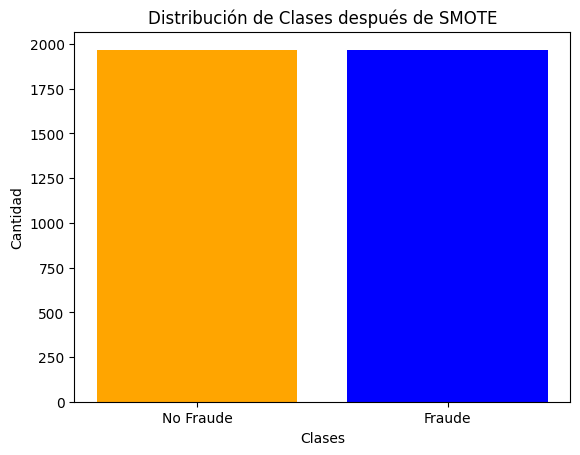

In [ ]:
class_counts = Counter(y)
plt.bar(class_counts.keys(), class_counts.values(), color=['blue', 'orange'])
plt.title('Distribución de Clases después de SMOTE')
plt.xlabel('Clases')
plt.ylabel('Cantidad')
plt.xticks([0, 1], labels=["No Fraude", "Fraude"])
plt.show()


# RED GAN 1

In [ ]:
# Dividimos el dataset por clase
df_fraude = df1[df1['Class'] == 1]
df_no_fraude = df1[df1['Class'] == 0]


## Generador

In [ ]:
DIM_RUIDO = 20 # hiperparámetro que hay que optimizar

modelo_generador = keras.models.Sequential([
	keras.layers.InputLayer(input_shape=[DIM_RUIDO]),#en el generador entra el ruido

	keras.layers.Dense(65, activation="sigmoid"), #capa densa, hay que optimizar
	#keras.layers.Dense(128, activation="sigmoid"),
# de un ruido 5 saco 9 filas y en el medio le pongo una capa densa, necesitaría más columnas
	# Capa de salida (cantidad de columnas de df)
	keras.layers.Dense(df1.shape[1], activation="sigmoid")
 ])

modelo_generador.summary()


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_22 (Dense)                     │ (None, 65)                  │           1,365 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_23 (Dense)                     │ (None, 31)                  │           2,046 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,411 (13.32 KB)

 Trainable params: 3,411 (13.32 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# probamos el modelo_generador

# generamos ruido al azar
ruido = tf.random.normal((1, DIM_RUIDO))
# en vez de normal podria usar datos uniformes, entre cero y uno

# generamos una imagen a partir del ruido
fila_generada = modelo_generador(ruido, training=False)

fila_generada

# se muestra la fila que se genero, con 9 columnas. como el df esta normalizado las columnas me dan entre cero y uno


<tf.Tensor: shape=(1, 31), dtype=float32, numpy=
array([[0.2669769 , 0.44530758, 0.6605649 , 0.6876214 , 0.566959  ,
        0.40886843, 0.34406477, 0.7085724 , 0.64398736, 0.4632608 ,
        0.4458352 , 0.598236  , 0.40532836, 0.6255068 , 0.6118138 ,
        0.65754527, 0.41967285, 0.42681098, 0.38837233, 0.6068319 ,
        0.54913086, 0.5179373 , 0.24483208, 0.5105388 , 0.22330472,
        0.5032303 , 0.58249605, 0.4902932 , 0.47571102, 0.7399702 ,
        0.46241727]], dtype=float32)>

## Discriminador

In [ ]:
modelo_discriminador = keras.models.Sequential([
    keras.layers.InputLayer(input_shape=[df1.shape[1]]), # entra una fila de 9 columnas

    keras.layers.Dense(64, activation="sigmoid"), # activo una capa densa de clase sigmoide
    #keras.layers.Dense(128, activation="sigmoid"),

    keras.layers.Dense(1, activation="sigmoid") #sale una columna de un solo dato qeu es para clasificación
])

modelo_discriminador.compile(loss="binary_crossentropy", optimizer="adam")
modelo_discriminador.summary()


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                     │ (None, 64)                  │           2,048 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,113 (8.25 KB)

 Trainable params: 2,113 (8.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# vemos cómo discrimina la imagen generada anteriormente
# un valor cercano a 0.5 significa que no puede saber si es 0 o 1
# 0,47 no sabe si es verdadera o no la fila
# el discriminador no esta entrenado, no hay mucho más para hacer
modelo_discriminador(fila_generada)


<tf.Tensor: shape=(1, 1), dtype=float32, numpy=array([[0.7244739]], dtype=float32)>

## Modelo adversario

In [ ]:
# vamos a entrenar al discrinador a mano
modelo_discriminador.trainable = False

modelo_gan = keras.models.Sequential([
    modelo_generador,
    modelo_discriminador
])

modelo_gan.compile(loss="binary_crossentropy", optimizer="adam") #probar con adam o algún otro


## Entrenamiento del modelo adversario

In [ ]:
EPOCHS = 50
BATCH_SIZE = 64


In [ ]:
for epoch in trange(EPOCHS, desc="epoch"):
    with trange(df1.shape[0] // BATCH_SIZE, desc="batch", leave=False) as t_batch:
        for n_batch in t_batch:
            ## Entrenamiento del discriminador
            X_real_fraude = df_fraude.sample(n=BATCH_SIZE // 4, replace=True).values
            X_real_no_fraude = df_no_fraude.sample(n=BATCH_SIZE // 4, replace=True).values
            X_real = np.concatenate((X_real_fraude, X_real_no_fraude))
            y_real = np.ones((BATCH_SIZE // 2, 1)) * 0.9

            X_fake = modelo_generador(np.random.randn(DIM_RUIDO * BATCH_SIZE // 2).reshape(BATCH_SIZE // 2, DIM_RUIDO))
            y_fake = np.zeros((BATCH_SIZE // 2, 1))

            X_train = np.concatenate((X_real, X_fake))
            y_train = np.concatenate((y_real, y_fake))

            discriminador_loss = modelo_discriminador.train_on_batch(X_train, y_train)

            ## Entrenamiento del generador
            X_gan = np.random.randn(DIM_RUIDO * BATCH_SIZE).reshape(BATCH_SIZE, DIM_RUIDO)
            y_gan = np.ones((BATCH_SIZE, 1))

            gan_loss = modelo_gan.train_on_batch(X_gan, y_gan)

            t_batch.set_postfix(discriminador_loss=f"{discriminador_loss}", gan_loss=f"{gan_loss}")

print("Final loss values:", discriminador_loss, gan_loss)


epoch:   0%|          | 0/50 [00:00<?, ?it/s]

batch:   0%|          | 0/38 [00:00<?, ?it/s]

batch:   0%|          | 0/38 [00:00<?, ?it/s]

batch:   0%|          | 0/38 [00:00<?, ?it/s]

batch:   0%|          | 0/38 [00:00<?, ?it/s]

...

batch:   0%|          | 0/38 [00:00<?, ?it/s]

batch:   0%|          | 0/38 [00:00<?, ?it/s]

batch:   0%|          | 0/38 [00:00<?, ?it/s]

batch:   0%|          | 0/38 [00:00<?, ?it/s]

Final loss values: 0.6197202 [array(0.6197202, dtype=float32), array(0.6197202, dtype=float32)]


In [ ]:
# Generamos 2000 registros ficticios
X_fake = modelo_generador(np.random.randn(DIM_RUIDO * 2000).reshape(2000, DIM_RUIDO))

# Validamos las proporciones
print("Proporciones en los datos generados:", np.mean(X_fake, axis=0))


Proporciones en los datos generados: [0.67735326 0.9837415  0.76146185 0.22862618 0.3109014  0.50689894
 0.76221585 0.20341988 0.96005106 0.1456692  0.8406516  0.7105639
 0.3022946  0.866885   0.826125   0.8216938  0.07202818 0.20180635
 0.29788545 0.12318173 0.31437218 0.84729    0.1814951  0.84182
 0.11720427 0.93491864 0.7407048  0.807767   0.594438   0.00474615
 0.23422533]


In [ ]:
discriminador_loss


array(0.6197202, dtype=float32)

In [ ]:
gan_loss


[array(0.6197202, dtype=float32), array(0.6197202, dtype=float32)]

In [ ]:
X_fake.shape


TensorShape([2000, 31])

In [ ]:
# Convertimos el tensor X_fake a un DataFrame
X_fake_df = pd.DataFrame(X_fake.numpy(), columns=[f"feature_{i}" for i in range(X_fake.shape[1])])


In [ ]:
# Renombramos la columna 'feature_30' a 'Class' y aplicamos el redondeo
X_fake_df.rename(columns={'feature_30': 'Class'}, inplace=True)
X_fake_df['Class'] = (X_fake_df['Class'] >= 0.5).astype(int)

# Verificamos el DataFrame resultante
X_fake_df


,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_21,feature_22,feature_23,feature_24,feature_25,feature_26,feature_27,feature_28,feature_29,Class
0,0.509787,0.882791,0.515386,0.422030,0.399433,0.489260,0.605282,0.392170,0.817547,0.360601,...,0.610534,0.409258,0.597016,0.365299,0.743181,0.602051,0.597113,0.491201,4.870348e-02,0
1,0.586834,0.957200,0.596389,0.374829,0.433279,0.548648,0.634975,0.369507,0.877893,0.298523,...,0.727925,0.273223,0.721789,0.257374,0.861689,0.568264,0.724983,0.557453,7.318734e-03,0
2,0.547016,0.987673,0.635458,0.303269,0.343726,0.474440,0.743241,0.239643,0.957311,0.209290,...,0.749281,0.227459,0.746468,0.179240,0.912890,0.715497,0.709802,0.530933,1.352340e-03,0
3,0.708360,0.998426,0.762627,0.220328,0.240773,0.482968,0.778273,0.155358,0.986598,0.110913,...,0.860826,0.189294,0.844059,0.065483,0.955351,0.754161,0.813723,0.549867,5.984442e-05,0
4,0.676784,0.996873,0.813642,0.205063,0.343498,0.542099,0.729065,0.246949,0.971733,0.129435,...,0.846220,0.217858,0.883389,0.094451,0.946253,0.725967,0.812751,0.707156,1.427538e-04,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,0.711042,0.995935,0.724283,0.230742,0.353730,0.542290,0.775533,0.249480,0.977342,0.165457,...,0.829404,0.215107,0.808974,0.118458,0.942153,0.728563,0.819700,0.582663,1.961228e-04,0
1996,0.780368,0.999987,0.908974,0.102687,0.217844,0.512470,0.901799,0.052493,0.999547,0.031577,...,0.969670,0.028912,0.977736,0.010850,0.996572,0.870019,0.947734,0.653739,2.329099e-08,0
1997,0.746783,0.999793,0.881916,0.139750,0.264393,0.507940,0.850130,0.111239,0.997194,0.064017,...,0.936524,0.098940,0.935706,0.039060,0.984583,0.828903,0.866650,0.674484,2.395049e-06,0
1998,0.757747,0.999939,0.903697,0.124849,0.230319,0.522593,0.895757,0.058247,0.998943,0.037380,...,0.947813,0.048258,0.958168,0.019681,0.992858,0.880247,0.908476,0.577846,2.238392e-07,0


In [ ]:
# Contamos cuántos registros hay para cada valor en la columna 'Class'
class_counts = X_fake_df['Class'].value_counts()

print(class_counts)


Class
0    1999
1       1
Name: count, dtype: int64


# RED GAN 2

In [ ]:
# Dividimos el dataset por clase
df_fraude = df1[df1['Class'] == 1]
df_no_fraude = df1[df1['Class'] == 0]


## Generador

In [ ]:
DIM_RUIDO = 15 # hiperparámetro que hay que optimizar

modelo_generador = keras.models.Sequential([
	keras.layers.InputLayer(input_shape=[DIM_RUIDO]),#en el generador entra el ruido

	keras.layers.Dense(65, activation="sigmoid"), #capa densa, hay que optimizar
	#keras.layers.Dense(128, activation="sigmoid"),
# de un ruido 5 saco 9 filas y en el medio le pongo una capa densa, necesitaría más columnas
	# Capa de salida (cantidad de columnas de df)
	keras.layers.Dense(df1.shape[1], activation="sigmoid")
 ])

modelo_generador.summary()


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                     │ (None, 65)                  │           1,365 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 31)                  │           2,046 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,411 (13.32 KB)

 Trainable params: 3,411 (13.32 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# probamos el modelo_generador

# generamos ruido al azar
ruido = tf.random.normal((1, DIM_RUIDO))
# en vez de normal podria usar datos uniformes, entre cero y uno

# generamos una imagen a partir del ruido
fila_generada = modelo_generador(ruido, training=False)

fila_generada

# se muestra la fila que se genero, con 9 columnas. como el df esta normalizado las columnas me dan entre cero y uno


<tf.Tensor: shape=(1, 31), dtype=float32, numpy=
array([[0.6671204 , 0.55971634, 0.5053745 , 0.56479627, 0.5441414 ,
        0.54449826, 0.37065232, 0.6000243 , 0.35650682, 0.26667923,
        0.46329024, 0.5038042 , 0.1908308 , 0.51362985, 0.57755995,
        0.30033162, 0.3134874 , 0.3603994 , 0.7837414 , 0.47507247,
        0.35806268, 0.31650952, 0.7019083 , 0.34909004, 0.5004647 ,
        0.7075924 , 0.35140485, 0.7392353 , 0.49975365, 0.50374687,
        0.5609142 ]], dtype=float32)>

## Discriminador

In [ ]:
modelo_discriminador = keras.models.Sequential([
    keras.layers.InputLayer(input_shape=[df1.shape[1]]), # entra una fila de 9 columnas

    keras.layers.Dense(64, activation="sigmoid"), # activo una capa densa de clase sigmoide
    #keras.layers.Dense(128, activation="sigmoid"),

    keras.layers.Dense(1, activation="sigmoid") #sale una columna de un solo dato qeu es para clasificación
])

modelo_discriminador.compile(loss="binary_crossentropy", optimizer="adam")
modelo_discriminador.summary()


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                     │ (None, 64)                  │           2,048 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,113 (8.25 KB)

 Trainable params: 2,113 (8.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# vemos cómo discrimina la imagen generada anteriormente
# un valor cercano a 0.5 significa que no puede saber si es 0 o 1
# 0,47 no sabe si es verdadera o no la fila
# el discriminador no esta entrenado, no hay mucho más para hacer
modelo_discriminador(fila_generada)


<tf.Tensor: shape=(1, 1), dtype=float32, numpy=array([[0.34080023]], dtype=float32)>

## Modelo adversario

In [ ]:
# vamos a entrenar al discrinador a mano
modelo_discriminador.trainable = False

modelo_gan = keras.models.Sequential([
    modelo_generador,
    modelo_discriminador
])

modelo_gan.compile(loss="binary_crossentropy", optimizer="adam") #probar con adam o algún otro


## Entrenamiento del modelo adversario

In [ ]:
EPOCHS = 50
BATCH_SIZE = 64


In [ ]:
for epoch in trange(EPOCHS, desc="epoch"):
    with trange(df1.shape[0] // BATCH_SIZE, desc="batch", leave=False) as t_batch:
        for n_batch in t_batch:
            ## Entrenamiento del discriminador
            X_real_fraude = df_fraude.sample(n=BATCH_SIZE // 4, replace=True).values
            X_real_no_fraude = df_no_fraude.sample(n=BATCH_SIZE // 4, replace=True).values
            X_real = np.concatenate((X_real_fraude, X_real_no_fraude))
            y_real = np.ones((BATCH_SIZE // 2, 1)) * 0.9

            X_fake = modelo_generador(np.random.randn(DIM_RUIDO * BATCH_SIZE // 2).reshape(BATCH_SIZE // 2, DIM_RUIDO))
            y_fake = np.zeros((BATCH_SIZE // 2, 1))

            X_train = np.concatenate((X_real, X_fake))
            y_train = np.concatenate((y_real, y_fake))

            discriminador_loss = modelo_discriminador.train_on_batch(X_train, y_train)

            ## Entrenamiento del generador
            X_gan = np.random.randn(DIM_RUIDO * BATCH_SIZE).reshape(BATCH_SIZE, DIM_RUIDO)
            y_gan = np.ones((BATCH_SIZE, 1))

            gan_loss = modelo_gan.train_on_batch(X_gan, y_gan)

            t_batch.set_postfix(discriminador_loss=f"{discriminador_loss}", gan_loss=f"{gan_loss}")

print("Final loss values:", discriminador_loss, gan_loss)


epoch:   0%|          | 0/50 [00:00<?, ?it/s]

batch:   0%|          | 0/38 [00:00<?, ?it/s]

batch:   0%|          | 0/38 [00:00<?, ?it/s]

batch:   0%|          | 0/38 [00:00<?, ?it/s]

batch:   0%|          | 0/38 [00:00<?, ?it/s]

...

batch:   0%|          | 0/38 [00:00<?, ?it/s]

batch:   0%|          | 0/38 [00:00<?, ?it/s]

batch:   0%|          | 0/38 [00:00<?, ?it/s]

batch:   0%|          | 0/38 [00:00<?, ?it/s]

Final loss values: 0.81403923 [array(0.81403923, dtype=float32), array(0.81403923, dtype=float32)]


In [ ]:
# Generamos 2000 registros ficticios
X_fake = modelo_generador(np.random.randn(DIM_RUIDO * 2000).reshape(2000, DIM_RUIDO))

# Validamos las proporciones
print("Proporciones en los datos generados:", np.mean(X_fake, axis=0))


Proporciones en los datos generados: [0.00410869 0.99055153 0.99335736 0.01306232 0.23690963 0.9914967
 0.00690988 0.49900544 0.00596321 0.9930169  0.99454546 0.99204123
 0.00732704 0.9927828  0.9927961  0.00478595 0.00712649 0.99313694
 0.991969   0.00435572 0.9924844  0.00706708 0.00517039 0.00372023
 0.99470115 0.9947919  0.9874041  0.00416253 0.00391438 0.00511895
 0.00632741]


In [ ]:
discriminador_loss


array(0.8087402, dtype=float32)

In [ ]:
gan_loss


[array(0.8087042, dtype=float32), array(0.8087042, dtype=float32)]

In [ ]:
X_fake.shape


TensorShape([2000, 31])

In [ ]:
# Convertimos el tensor X_fake a un DataFrame
X_fake_df = pd.DataFrame(X_fake.numpy(), columns=[f"feature_{i}" for i in range(X_fake.shape[1])])


In [ ]:
# Renombramos la columna 'feature_30' a 'Class' y aplicamos el redondeo
X_fake_df.rename(columns={'feature_30': 'Class'}, inplace=True)
X_fake_df['Class'] = (X_fake_df['Class'] >= 0.5).astype(int)

# Verificamos el DataFrame resultante
X_fake_df


,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_21,feature_22,feature_23,feature_24,feature_25,feature_26,feature_27,feature_28,feature_29,Class
0,0.004157,0.992260,0.994187,0.013936,0.208791,0.992342,0.006115,0.471707,0.005863,0.993280,...,0.006663,0.005009,0.003654,0.994738,0.994811,0.987684,0.004192,0.003467,0.004704,0
1,0.004317,0.990411,0.993791,0.014757,0.225785,0.990952,0.006818,0.471710,0.005542,0.993050,...,0.007295,0.005769,0.004131,0.994871,0.995309,0.990170,0.006155,0.003976,0.005254,0
2,0.004368,0.992152,0.993270,0.015350,0.277210,0.990084,0.007970,0.497209,0.006486,0.992877,...,0.009461,0.005425,0.003332,0.993860,0.994239,0.986074,0.003768,0.004074,0.005222,0
3,0.003665,0.991087,0.992621,0.012384,0.289027,0.989741,0.007382,0.492628,0.005360,0.992368,...,0.007188,0.005244,0.003843,0.994573,0.995314,0.988738,0.003496,0.004040,0.005734,0
4,0.004158,0.991098,0.993968,0.015456,0.272944,0.991283,0.007809,0.438083,0.005441,0.990919,...,0.007544,0.004522,0.003814,0.994779,0.994972,0.987072,0.003959,0.004714,0.005688,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,0.004027,0.991046,0.992736,0.013080,0.276969,0.989678,0.007298,0.498585,0.005803,0.993415,...,0.007361,0.005337,0.003457,0.994829,0.994800,0.988818,0.004010,0.003968,0.005239,0
1996,0.004159,0.989851,0.992350,0.011647,0.249934,0.991220,0.005935,0.536026,0.005732,0.994261,...,0.007097,0.004882,0.003456,0.994423,0.993631,0.987229,0.003638,0.003747,0.004739,0
1997,0.004554,0.990204,0.993829,0.015923,0.179310,0.993129,0.007447,0.485360,0.007160,0.992296,...,0.007965,0.006061,0.005234,0.994695,0.995117,0.986621,0.005771,0.003736,0.005455,0
1998,0.004226,0.989912,0.993996,0.013192,0.203910,0.992852,0.006221,0.486663,0.005882,0.992497,...,0.005704,0.005091,0.003904,0.995344,0.995338,0.987554,0.005217,0.003978,0.004964,0


In [ ]:
# Contamos cuántos registros hay para cada valor en la columna 'Class'
class_counts = X_fake_df['Class'].value_counts()

print(class_counts)


Class
0    2000
Name: count, dtype: int64


# RED GAN 3

In [ ]:
# Dividimos el dataset por clase
df_fraude = df1[df1['Class'] == 1]
df_no_fraude = df1[df1['Class'] == 0]


## Generador

In [ ]:
DIM_RUIDO = 20 # hiperparámetro que hay que optimizar

modelo_generador = keras.models.Sequential([
	keras.layers.InputLayer(input_shape=[DIM_RUIDO]),#en el generador entra el ruido

	keras.layers.Dense(65, activation="sigmoid"), #capa densa, hay que optimizar
	#keras.layers.Dense(128, activation="sigmoid"),
# de un ruido 5 saco 9 filas y en el medio le pongo una capa densa, necesitaría más columnas
	# Capa de salida (cantidad de columnas de df)
	keras.layers.Dense(df1.shape[1], activation="sigmoid")
 ])

modelo_generador.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                      │ (None, 65)                  │           1,365 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 31)                  │           2,046 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,411 (13.32 KB)

 Trainable params: 3,411 (13.32 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# probamos el modelo_generador

# generamos ruido al azar
ruido = tf.random.normal((1, DIM_RUIDO))
# en vez de normal podria usar datos uniformes, entre cero y uno

# generamos una imagen a partir del ruido
fila_generada = modelo_generador(ruido, training=False)

fila_generada

# se muestra la fila que se genero, con 9 columnas. como el df esta normalizado las columnas me dan entre cero y uno


<tf.Tensor: shape=(1, 31), dtype=float32, numpy=
array([[0.57678837, 0.34958425, 0.5787152 , 0.61812335, 0.7004646 ,
        0.4278952 , 0.5588697 , 0.6182595 , 0.3517342 , 0.5597505 ,
        0.44417945, 0.31054908, 0.58303297, 0.68188906, 0.41583648,
        0.66713697, 0.5116772 , 0.35211584, 0.40762082, 0.4018488 ,
        0.60911405, 0.35248968, 0.36716753, 0.7805484 , 0.6761711 ,
        0.40054157, 0.43536878, 0.7296333 , 0.4452208 , 0.5433153 ,
        0.3961297 ]], dtype=float32)>

## Discriminador

In [ ]:
modelo_discriminador = keras.models.Sequential([
    keras.layers.InputLayer(input_shape=[df1.shape[1]]), # entra una fila de 9 columnas

    keras.layers.Dense(64, activation="sigmoid"), # activo una capa densa de clase sigmoide
    #keras.layers.Dense(128, activation="sigmoid"),

    keras.layers.Dense(1, activation="sigmoid") #sale una columna de un solo dato qeu es para clasificación
])

modelo_discriminador.compile(loss="binary_crossentropy", optimizer="adam")
modelo_discriminador.summary()


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                      │ (None, 64)                  │           2,048 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,113 (8.25 KB)

 Trainable params: 2,113 (8.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# vemos cómo discrimina la imagen generada anteriormente
# un valor cercano a 0.5 significa que no puede saber si es 0 o 1
# 0,47 no sabe si es verdadera o no la fila
# el discriminador no esta entrenado, no hay mucho más para hacer
modelo_discriminador(fila_generada)


<tf.Tensor: shape=(1, 1), dtype=float32, numpy=array([[0.51148415]], dtype=float32)>

## Modelo adversario

In [ ]:
# vamos a entrenar al discrinador a mano
modelo_discriminador.trainable = False

modelo_gan = keras.models.Sequential([
    modelo_generador,
    modelo_discriminador
])

modelo_gan.compile(loss="binary_crossentropy", optimizer="adam") #probar con adam o algún otro


## Entrenamiento del modelo adversario

In [ ]:
EPOCHS = 50
BATCH_SIZE = 64


In [ ]:
for epoch in trange(EPOCHS, desc="epoch"):
    with trange(df1.shape[0] // BATCH_SIZE, desc="batch", leave=False) as t_batch:
        for n_batch in t_batch:
            ## Entrenamiento del discriminador
            X_real_fraude = df_fraude.sample(n=BATCH_SIZE // 4, replace=True).values
            X_real_no_fraude = df_no_fraude.sample(n=BATCH_SIZE // 4, replace=True).values
            X_real = np.concatenate((X_real_fraude, X_real_no_fraude))
            y_real = np.ones((BATCH_SIZE // 2, 1)) * 0.9

            X_fake = modelo_generador(np.random.randn(DIM_RUIDO * BATCH_SIZE // 2).reshape(BATCH_SIZE // 2, DIM_RUIDO))
            y_fake = np.zeros((BATCH_SIZE // 2, 1))

            X_train = np.concatenate((X_real, X_fake))
            y_train = np.concatenate((y_real, y_fake))

            discriminador_loss = modelo_discriminador.train_on_batch(X_train, y_train)

            ## Entrenamiento del generador
            X_gan = np.random.randn(DIM_RUIDO * BATCH_SIZE).reshape(BATCH_SIZE, DIM_RUIDO)
            y_gan = np.ones((BATCH_SIZE, 1))

            gan_loss = modelo_gan.train_on_batch(X_gan, y_gan)

            t_batch.set_postfix(discriminador_loss=f"{discriminador_loss}", gan_loss=f"{gan_loss}")

print("Final loss values:", discriminador_loss, gan_loss)


epoch:   0%|          | 0/50 [00:00<?, ?it/s]

batch:   0%|          | 0/38 [00:00<?, ?it/s]

batch:   0%|          | 0/38 [00:00<?, ?it/s]

batch:   0%|          | 0/38 [00:00<?, ?it/s]

batch:   0%|          | 0/38 [00:00<?, ?it/s]

...

batch:   0%|          | 0/38 [00:00<?, ?it/s]

batch:   0%|          | 0/38 [00:00<?, ?it/s]

batch:   0%|          | 0/38 [00:00<?, ?it/s]

batch:   0%|          | 0/38 [00:00<?, ?it/s]

Final loss values: 0.8996078 [array(0.8996078, dtype=float32), array(0.8996078, dtype=float32)]


In [ ]:
# Generamos 2000 registros ficticios
X_fake = modelo_generador(np.random.randn(DIM_RUIDO * 2000).reshape(2000, DIM_RUIDO))

# Validamos las proporciones
print("Proporciones en los datos generados:", np.mean(X_fake, axis=0))


Proporciones en los datos generados: [9.9954998e-01 3.7883839e-04 9.9944872e-01 5.9937959e-04 6.7981571e-04
 9.9930847e-01 6.3326454e-04 6.3836790e-04 6.4953911e-04 9.9949467e-01
 5.0788780e-04 3.8783593e-04 9.9956065e-01 9.9948668e-01 9.9931729e-01
 6.8728067e-04 9.9943823e-01 9.9941236e-01 5.0426112e-04 4.4448991e-04
 9.9950212e-01 9.9935424e-01 9.9925172e-01 1.2292851e-03 6.7059527e-04
 9.9924326e-01 4.6745024e-04 9.9969226e-01 4.4449352e-04 5.4243649e-04
 9.9934316e-01]


In [ ]:
discriminador_loss


array(0.8996078, dtype=float32)

In [ ]:
gan_loss


[array(0.8996078, dtype=float32), array(0.8996078, dtype=float32)]

In [ ]:
X_fake.shape


TensorShape([2000, 31])

In [ ]:
# Convertimos el tensor X_fake a un DataFrame
X_fake_df = pd.DataFrame(X_fake.numpy(), columns=[f"feature_{i}" for i in range(X_fake.shape[1])])


In [ ]:
# Renombramos la columna 'feature_30' a 'Class' y aplicamos el redondeo
X_fake_df.rename(columns={'feature_30': 'Class'}, inplace=True)
X_fake_df['Class'] = (X_fake_df['Class'] >= 0.5).astype(int)

# Verificamos el DataFrame resultante
X_fake_df


,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_21,feature_22,feature_23,feature_24,feature_25,feature_26,feature_27,feature_28,feature_29,Class
0,0.999625,0.000409,0.999502,0.000609,0.000675,0.999219,0.000666,0.000484,0.000661,0.999508,...,0.999323,0.999180,0.001511,0.000750,0.999417,0.000497,0.999742,0.000469,0.000490,1
1,0.999584,0.000372,0.999439,0.000523,0.000689,0.999404,0.000656,0.000627,0.000636,0.999552,...,0.999386,0.999220,0.001180,0.000654,0.999176,0.000531,0.999736,0.000441,0.000617,1
2,0.999552,0.000385,0.999405,0.000562,0.000745,0.999355,0.000597,0.000799,0.000814,0.999513,...,0.999378,0.999309,0.001226,0.000605,0.999197,0.000492,0.999644,0.000435,0.000546,1
3,0.999561,0.000371,0.999467,0.000637,0.000708,0.999226,0.000635,0.000657,0.000663,0.999483,...,0.999287,0.999295,0.001456,0.000625,0.999269,0.000418,0.999696,0.000478,0.000527,1
4,0.999557,0.000356,0.999429,0.000581,0.000638,0.999276,0.000573,0.000655,0.000586,0.999467,...,0.999405,0.999296,0.001108,0.000662,0.999292,0.000422,0.999728,0.000388,0.000500,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,0.999498,0.000371,0.999378,0.000517,0.000652,0.999453,0.000686,0.000644,0.000601,0.999522,...,0.999342,0.999202,0.001018,0.000679,0.999129,0.000512,0.999621,0.000394,0.000599,1
1996,0.999460,0.000370,0.999452,0.000584,0.000762,0.999327,0.000640,0.000629,0.000759,0.999474,...,0.999363,0.999256,0.001047,0.000666,0.999116,0.000491,0.999644,0.000483,0.000598,1
1997,0.999571,0.000385,0.999508,0.000575,0.000636,0.999314,0.000627,0.000715,0.000717,0.999509,...,0.999354,0.999390,0.001218,0.000620,0.999282,0.000448,0.999664,0.000449,0.000499,1
1998,0.999584,0.000365,0.999490,0.000538,0.000680,0.999236,0.000623,0.000608,0.000697,0.999495,...,0.999330,0.999193,0.001329,0.000743,0.999280,0.000478,0.999746,0.000341,0.000520,1


In [ ]:
# Contamos cuántos registros hay para cada valor en la columna 'Class'
class_counts = X_fake_df['Class'].value_counts()

print(class_counts)


Class
1    2000
Name: count, dtype: int64


In [ ]:
print(X_fake_df.columns)
print(df1.columns)


Index(['feature_0', 'feature_1', 'feature_2', 'feature_3', 'feature_4',
       'feature_5', 'feature_6', 'feature_7', 'feature_8', 'feature_9',
       'feature_10', 'feature_11', 'feature_12', 'feature_13', 'feature_14',
       'feature_15', 'feature_16', 'feature_17', 'feature_18', 'feature_19',
       'feature_20', 'feature_21', 'feature_22', 'feature_23', 'feature_24',
       'feature_25', 'feature_26', 'feature_27', 'feature_28', 'feature_29',
       'Class'],
      dtype='object')
Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')


In [ ]:
# Unir los DataFrames sin errores
df2 = pd.concat([df1, X_fake_df], axis=0, ignore_index=True)

# Verificar el DataFrame combinado
df2.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4460 entries, 0 to 4459
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    4460 non-null   float64
 1   V1      4460 non-null   float64
 2   V2      4460 non-null   float64
 3   V3      4460 non-null   float64
 4   V4      4460 non-null   float64
 5   V5      4460 non-null   float64
 6   V6      4460 non-null   float64
 7   V7      4460 non-null   float64
 8   V8      4460 non-null   float64
 9   V9      4460 non-null   float64
 10  V10     4460 non-null   float64
 11  V11     4460 non-null   float64
 12  V12     4460 non-null   float64
 13  V13     4460 non-null   float64
 14  V14     4460 non-null   float64
 15  V15     4460 non-null   float64
 16  V16     4460 non-null   float64
 17  V17     4460 non-null   float64
 18  V18     4460 non-null   float64
 19  V19     4460 non-null   float64
 20  V20     4460 non-null   float64
 21  V21     4460 non-null   float64
 22  

## GAN + MODELOS

In [ ]:
# Datos para probar
X = df2[df2.columns.drop('Class')]
y = df2['Class']

# Convertir los nuevos datos del generador en binario (0 o 1) antes del split
y = y.round().astype(int)  # Redondear al valor entero más cercano (0 o 1)

# Partir en 80% de entrenamiento y 20% de prueba
if len(np.unique(y)) > 1:
    X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(X, y, test_size=0.2, shuffle=True, stratify=y, random_state=42)
else:
    print("Warning: La columna 'Outcome' solo contiene una clase. La estratificación no es posible.")
    X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(X, y, test_size=0.2, shuffle=True, random_state=42)


### MODELO 1 "Decision Tree"

In [ ]:
# Definir la función para calcular métricas
def f1_precision_recall(X, y): #Le doy el x e y
# Dividir los datos en entrenamiento y prueba (50% cada uno, con estratificación)
    X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(X, y, test_size=0.5, shuffle=True, stratify=y, random_state=42)

# Crear y entrenar el modelo de árbol de decisión
    clf = sk.tree.DecisionTreeClassifier(random_state=42)
    clf.fit(X_train, y_train) #lo entrena
    y_pred = clf.predict(X_test) #predice

# Imprimir las métricas
    print("f1:", sk.metrics.f1_score(y_test, y_pred))
    print("precision:", sk.metrics.precision_score(y_test, y_pred))
    print("recall:", sk.metrics.recall_score(y_test, y_pred))


f1_precision_recall(X, y)


f1: 0.9707414829659319
precision: 0.9695756605284227
recall: 0.9719101123595506


### MODELO 2 "Random Forest"


In [ ]:
# Definir la función para calcular métricas
def f1_precision_recall(X, y):
    # Dividir los datos en entrenamiento y prueba (50% cada uno, con estratificación)
    X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(
        X, y, test_size=0.5, shuffle=True, stratify=y, random_state=42
    )

    # Crear y entrenar el modelo Random Forest
    clf = sk.ensemble.RandomForestClassifier(random_state=42)
    clf.fit(X_train, y_train)  # Entrenar el modelo
    y_pred = clf.predict(X_test)  # Predecir en el conjunto de prueba

    # Imprimir las métricas
    print("f1:", sk.metrics.f1_score(y_test, y_pred))
    print("precision:", sk.metrics.precision_score(y_test, y_pred))
    print("recall:", sk.metrics.recall_score(y_test, y_pred))

f1_precision_recall(X, y)


f1: 0.9849898580121704
precision: 0.9958982772764561
recall: 0.9743178170144462


### MODELO 3 "Gradient Boosting"

In [ ]:
# Dividir los datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, stratify=y, random_state=42)

# Crear el modelo Gradient Boosting
gbt = GradientBoostingClassifier(random_state=42)

# Entrenar el modelo
gbt.fit(X_train, y_train)

# Predecir en los datos de prueba
y_pred = gbt.predict(X_test)

# Evaluar el modelo
print("F1:", f1_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))


F1: 0.9830234438156831
Precision: 0.990228013029316
Recall: 0.9759229534510433
